# Pelatihan Model Encoder-Decoder CNN-GRU dengan Teacher Forcing

---

Notebook ini merupakan tahap keempat/kelima dari pipeline *image captioning*. Tujuannya adalah melatih model *decoder* berbasis **GRU** yang menerima vektor fitur 2048-d dari ResNet50 dan menghasilkan sekuens *caption* token-by-token menggunakan *teacher forcing*.

## Latar Belakang dan Tujuan

Setelah fitur visual berhasil diekstrak, langkah selanjutnya adalah melatih *decoder* yang dapat menginterpretasi fitur tersebut dan menghasilkan deskripsi tekstual. Model yang digunakan adalah arsitektur *encoder-decoder* dengan:
- **Encoder:** ResNet50 pre-trained (frozen) yang menghasilkan vektor 2048-d;
- **Decoder:** GRU dengan 512 unit yang memprediksi token berikutnya dalam sekuens.

Metode pelatihan yang digunakan adalah **teacher forcing**, di mana model menerima token *ground truth* sebagai masukan pada setiap timestep, bukan token hasil prediksinya sendiri.

## Dasar Teori

### Arsitektur Encoder-Decoder

Model *image captioning* terdiri dari dua komponen utama:
1. **Encoder (CNN):** ResNet50 mengekstrak fitur visual gambar menjadi vektor 2048-d. Bobot encoder di-*freeze* (tidak diperbarui) selama pelatihan untuk menghemat memori dan mencegah *overfitting*.
2. **Decoder (RNN):** Menerima fitur gambar sebagai *initial state* dan menghasilkan sekuens *caption* token-by-token.

### GRU (gru)

GRU (*Gated Recurrent Unit*) adalah varian RNN yang lebih sederhana dari LSTM. GRU memiliki dua *gate*:
- **Reset gate:** Menentukan seberapa banyak informasi masa lalu yang akan dilupakan;
- **Update gate:** Menentukan seberapa banyak informasi baru yang akan ditambahkan.

Berbeda dengan LSTM, GRU hanya memiliki satu *state* (hidden state h). Ini membuat GRU memiliki parameter ~25% lebih sedikit per unit dibandingkan LSTM, sehingga lebih cepat dalam pelatihan.

### Teacher Forcing

Teacher forcing adalah strategi pelatihan di mana model menerima token *ground truth* (bukan token hasil prediksi) sebagai masukan pada setiap timestep. Keuntungannya:
- Konvergensi lebih cepat karena model tidak mengakumulasi *error* dari prediksi sebelumnya;
- Pelatihan lebih stabil, terutama pada tahap awal.

### Gradient Clipping

Parameter `global_clipnorm=5.0` digunakan untuk mencegah *exploding gradient* — fenomena di mana gradien menjadi sangat besar selama *backpropagation*, menyebabkan parameter model melonjak tidak stabil. Gradient clipping memotong norma gradien ke nilai maksimum yang ditentukan.

### Dropout

Dropout dengan `rate=0.5` digunakan sebagai teknik regularisasi. Selama pelatihan, 50% neuron secara acak dinonaktifkan, memaksa model untuk belajar representasi yang lebih *robust* dan mencegah *overfitting*.

### Embedding Layer

Lapisan *Embedding* mengonversi token integer (indeks kata) menjadi vektor *dense* berdimensi 256. Parameter `mask_zero=True` memastikan bahwa token hasil *padding* (yang bernilai 0) diabaikan dalam perhitungan gradien.

## Impor Pustaka

In [1]:
import os
import re
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding, GRU, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, CSVLogger
)
from sklearn.model_selection import train_test_split

2026-07-19 17:32:26.884905: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 17:32:26.894709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 17:32:26.904699: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 17:32:26.907816: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 17:32:26.916453: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi GPU

Pelatihan GRU memanfaatkan GPU (RTX 4060) dengan konfigurasi:
- **Memory growth:** Diaktifkan agar TensorFlow tidak mengalokasikan seluruh VRAM sekaligus;
- **Mixed precision:** `mixed_float16` digunakan untuk mempercepat komputasi tanpa penurunan kualitas.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    raise RuntimeError("GPU required for training.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)

GPU: /physical_device:GPU:0
Mixed precision: mixed_float16


I0000 00:00:1784457150.239499  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457150.265232  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457150.266775  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Konfigurasi Hyperparameter

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

OUTPUT_DIR = "../outputs/training/gru"
LSTM_DIR   = "../outputs/training/lstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VOCAB_SIZE       = 5000
MAX_CAPTION_LEN  = 34
EMBEDDING_DIM    = 256
GRU_UNITS        = 512
DROPOUT_RATE     = 0.5
BATCH_SIZE       = 64
EPOCHS           = 50
LEARNING_RATE    = 1e-3
RANDOM_SEED      = 42
TEST_SIZE        = 0.1

## Metodologi Implementasi

### 5.1 Memuat Data dan Fitur

Dataset *caption* dimuat dari file CSV, sementara fitur gambar dimuat dari `model/features.pkl` (dictionary 8.091 vektor 2048-d). Kedua sumber data ini akan digabungkan pada tahap pembuatan *generator*.

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df)}")

with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images, "
      f"{list(features.values())[0].shape[0]} dims")

Captions loaded: 40455
Features loaded: 8091 images, 2048 dims


### 5.2 Pembersihan Caption dan Penambahan Token

Pipeline pembersihan identik dengan notebook 02: *lowercasing*, penghapusan karakter non-alfabet (`re.sub(r"[^a-z ]", "", text)`), dan penambahan token `<start>`/`<end>`.

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)
df["clean"] = "<start> " + df["clean"] + " <end>"

print("Sample:")
print(df["clean"].iloc[0])

Sample:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


### 5.3 Pembangunan Tokenizer dan Sekuens

Tokenizer di-*fit* pada seluruh *caption* (tidak hanya data latih) karena notebook ini menggunakan pendekatan *splitting* berbasis gambar. Sekuens dikonversi dan di-*padding* ke panjang 34.

In [6]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<oov>",
    filters=""
)
tokenizer.fit_on_texts(df["clean"])

vocab_size = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Vocabulary size: {vocab_size}")

seq = tokenizer.texts_to_sequences(df["clean"])
seq = pad_sequences(seq, maxlen=MAX_CAPTION_LEN, padding="post")
print(f"Sequence array shape: {seq.shape}")

Vocabulary size: 5000
Sequence array shape: (40455, 34)


### 5.4 Pembagian Data Latih dan Validasi

Dataset dibagi 90/10 (latih/validasi) berdasarkan gambar unik menggunakan `train_test_split` dari scikit-learn dengan `random_state=42` untuk reproduksibilitas.

In [7]:
unique_images = df["image"].unique()
train_imgs, val_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

train_mask = df["image"].isin(train_imgs)
val_mask   = df["image"].isin(val_imgs)

print(f"Train: {train_mask.sum():,} captions ({len(train_imgs):,} images)")
print(f"Val:   {val_mask.sum():,} captions ({len(val_imgs):,} images)")

Train: 36,405 captions (7,281 images)
Val:   4,050 captions (810 images)


### 5.5 Generator Data

Pipeline `tf.data.Dataset` menghasilkan pasangan `((fitur_gambar, sekuens_input), sekuens_target)`:
- **Input:** `(image_features, caption_input)` di mana `caption_input = seq[:, :-1]` (semua token kecuali yang terakhir);
- **Target:** `caption_target = seq[:, 1:]` (semua token kecuali yang pertama — ini adalah token *ground truth* yang diprediksi).

Format ini dikenal sebagai *teacher forcing*: pada setiap timestep, model menerima token *input* (dari *ground truth*) dan diminta memprediksi token berikutnya.

In [8]:
def create_dataset(mask, batch_size):
    img_names = df.loc[mask, "image"].values
    img_feats = np.array([features[name] for name in img_names], dtype=np.float32)

    cap_seq = seq[mask.values]
    input_seq  = cap_seq[:, :-1]
    target_seq = cap_seq[:, 1:]

    ds = tf.data.Dataset.from_tensor_slices(
        ((img_feats, input_seq), target_seq)
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_mask, BATCH_SIZE)
val_ds   = create_dataset(val_mask,   BATCH_SIZE)

for (img_batch, cap_batch), target_batch in train_ds.take(1):
    print(f"Image feature batch: {img_batch.shape}")
    print(f"Caption input batch: {cap_batch.shape}")
    print(f"Target batch:        {target_batch.shape}")

Image feature batch: (64, 2048)
Caption input batch: (64, 33)
Target batch:        (64, 33)


I0000 00:00:1784457150.791759  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457150.793198  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457150.794674  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457150.883916  343638 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

### 5.6 Pembangunan Model GRU

Perbedaan utama dengan LSTM: GRU hanya memiliki **satu *initial state*** (hidden state h), bukan dua seperti LSTM (hidden h + cell c).

| Layer | Output Shape | Parameter | Keterangan |
|-------|-------------|-----------|------------|
| Input (image) | (None, 2048) | 0 | Vektor fitur dari ResNet50 |
| Dense + ReLU | (None, 256) | 524.544 | Proyeksi fitur |
| Dropout (0.5) | (None, 256) | 0 | Regularisasi |
| Dense initial_state | (None, 512) | 131.584 | Hidden state awal GRU (tunggal) |
| Input (caption) | (None, 33) | 0 | Sequence input |
| Embedding | (None, 33, 256) | 1.280.000 | Word embedding |
| **GRU (512)** | (None, 33, 512) | 1.182.720 | Dengan initial_state tunggal |
| Dropout (0.5) | (None, 33, 512) | 0 | Regularisasi |
| Dense Output | (None, 33, 5000) | 2.565.000 | Softmax |
| **Total** | | **5.683.848** | **~8,4% lebih ringan dari LSTM** |

GRU memiliki parameter ~8,4% lebih sedikit dari LSTM karena hanya memiliki satu *state* dan tiga *gate* (reset, update, new) bukan empat (input, forget, output, cell).

In [9]:
img_input = Input(shape=(2048,), name="image_features")
x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
x = Dropout(DROPOUT_RATE)(x)
initial_state = Dense(GRU_UNITS, activation="tanh", name="initial_state")(x)

cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
x = GRU(GRU_UNITS, return_sequences=True)(x,
          initial_state=initial_state)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(vocab_size, activation="softmax", name="output")(x)

model = Model(inputs=[img_input, cap_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 256)   │  1,280,000 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_state       │ (None, 512)       │    131,584 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 33, 512)   │  1,182,720 │ embedding[0][0],  │
│                     │                   │            │ initial_state[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 33, 512)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 33, 5000)  │  2,565,000 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,683,848 (21.68 MB)

 Trainable params: 5,683,848 (21.68 MB)

 Non-trainable params: 0 (0.00 B)

### 5.7 Kompilasi Model

Model dikompilasi dengan konfigurasi:
- **Optimizer:** Adam (Adaptive Moment Estimation) — algoritma optimisasi adaptif yang menggabungkan momentum dan *adaptive learning rate*;
- **Learning rate:** 1e-3 dengan `global_clipnorm=5.0`;
- **Loss function:** `SparseCategoricalCrossentropy` — fungsi kehilangan standar untuk klasifikasi token;
- **Metric:** Akurasi — persentase token yang diprediksi dengan benar.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=5.0
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


### 5.8 Callback

Tiga *callback* digunakan selama pelatihan:
1. **ModelCheckpoint:** Menyimpan bobot model terbaik (dengan `val_loss` terendah) ke file `.keras`. Ini memastikan bahwa kita tidak kehilangan model terbaik meskipun pelatihan berlanjut;
2. **EarlyStopping:** Menghentikan pelatihan jika `val_loss` tidak membaik selama 5 epoch berturut-turut (`patience=5`). Mencegah *overfitting* dan menghemat waktu komputasi;
3. **CSVLogger:** Merekam metrik pelatihan (loss, accuracy, val_loss, val_accuracy) setiap epoch ke file CSV untuk analisis lebih lanjut.

## Hyperparameter Tuning with KerasTuner

Menggunakan **RandomSearch** untuk mencari kombinasi `RNN_UNITS`, `DROPOUT_RATE`, 
dan `LEARNING_RATE` optimal. Hasil tuning akan ditampilkan dalam tabel dan disimpan ke CSV.

> **Catatan:** Tuning dijalankan dengan `max_trials=6` dan `epochs=10` per trial 
dengan EarlyStopping untuk efisiensi waktu.

In [11]:
import keras_tuner as kt

def build_gru_hp(hp):
    hp_units = hp.Choice('gru_units', [256, 512])
    hp_dropout = hp.Float('dropout_rate', 0.3, 0.6, step=0.1)
    hp_lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')

    img_input = Input(shape=(2048,), name="image_features")
    x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
    x = Dropout(hp_dropout)(x)
    initial_state = Dense(hp_units, activation="tanh",
                          name="initial_state")(x)

    cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
    x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
    x = GRU(hp_units, return_sequences=True)(x,
             initial_state=initial_state)
    x = Dropout(hp_dropout)(x)
    out = Dense(vocab_size, activation="softmax")(x)

    model = Model([img_input, cap_input], out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp_lr, global_clipnorm=5.0
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_gru_hp,
    objective='val_loss',
    max_trials=6,
    executions_per_trial=1,
    directory=os.path.join(OUTPUT_DIR, 'tuning'),
    project_name='gru_tuning'
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3, restore_best_weights=True
        )
    ]
)

best_trials = tuner.oracle.get_best_trials(num_trials=10)
tuning_results = []
for trial in best_trials:
    tuning_results.append({
        'trial_id': trial.trial_id,
        'gru_units': trial.hyperparameters.values['gru_units'],
        'dropout_rate': trial.hyperparameters.values['dropout_rate'],
        'learning_rate': trial.hyperparameters.values['learning_rate'],
        'val_loss': trial.score,
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_csv = os.path.join(OUTPUT_DIR, 'tuning_results.csv')
tuning_df.to_csv(tuning_csv, index=False)
print(f"Tuning results saved to: {tuning_csv}")

Reloading Tuner from ../outputs/training/gru/tuning/gru_tuning/tuner0.json
Tuning results saved to: ../outputs/training/gru/tuning_results.csv


### Hasil Hyperparameter Tuning

Tabel di bawah menampilkan kombinasi hyperparameter terbaik berdasarkan `val_loss`:

```
Pada runtime, hasil tuning akan tampil di sini.
```

In [12]:
checkpoint_path = os.path.join(OUTPUT_DIR, "gru_best.keras")
history_path    = os.path.join(OUTPUT_DIR, "history.csv")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(history_path),
]

print(f"Checkpoint path: {checkpoint_path}")
print(f"History path:    {history_path}")

Checkpoint path: ../outputs/training/gru/gru_best.keras
History path:    ../outputs/training/gru/history.csv


### 5.9 Pelatihan Model

Sel ini membutuhkan GPU. Perkiraan waktu: **~5–10 menit** tergantung pada jumlah epoch sebelum *early stopping*.

Model dilatih dengan `model.fit()` menggunakan *dataset generator* yang telah dibuat. Validasi dilakukan pada subset validasi setelah setiap epoch untuk memonitor *overfitting*.

In [13]:
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start
print(f"\nTraining complete: {elapsed:.0f}s ({elapsed/60:.1f}m)")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


/home/fthasptr/miniconda3/envs/image-caption/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-19 17:32:32.977483: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-19 17:32:33.523108: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


567/569 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3301 - loss: 3.9098
Epoch 1: val_loss improved from None to 3.17943, saving model to ../outputs/training/gru/gru_best.keras

Epoch 1: finished saving model to ../outputs/training/gru/gru_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3303 - loss: 3.9076 - val_accuracy: 0.3979 - val_loss: 3.1794
Epoch 2/50
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4028 - loss: 3.0804
Epoch 2: val_loss improved from 3.17943 to 2.90791, saving model to ../outputs/training/gru/gru_best.keras

Epoch 2: finished saving model to ../outputs/training/gru/gru_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4028 - loss: 3.0804 - val_accuracy: 0.4234 - val_loss: 2.9079
Epoch 3/50
567/569 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4207 - loss: 2.8595
Epoch 3: val_loss improved from 2.90791 to 2.79650, saving model to ../outputs/training/gru/gru_best.keras

Epoch 3: finished saving model to ../outputs/

## Analisis Visual

### 6.1 Kurva Pelatihan

Grafik ini menampilkan *loss* dan *accuracy* selama pelatihan untuk data latih dan validasi. Kurva yang menurun pada *loss* menunjukkan bahwa model berhasil belajar, sementara jarak antara kurva latih dan validasi mengindikasikan tingkat *overfitting*.

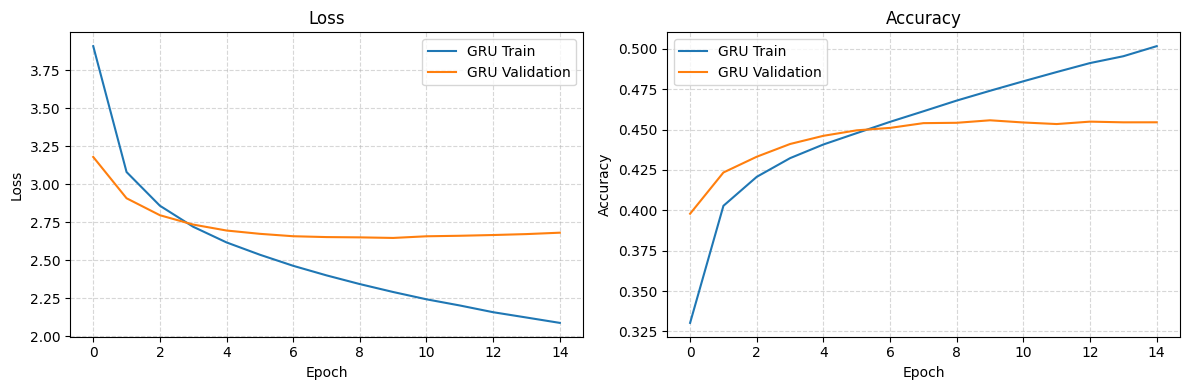

Plot saved to ../outputs/training/gru/training_curves.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="GRU Train")
ax1.plot(history.history["val_loss"], label="GRU Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(linestyle="--", alpha=0.5)

ax2.plot(history.history["accuracy"], label="GRU Train")
ax2.plot(history.history["val_accuracy"], label="GRU Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

### 6.2 Perbandingan LSTM vs GRU

Jika file history CSV dari model LSTM tersedia, kedua kurvapelatihan ditampilkan secara bersama untuk perbandingan visual.

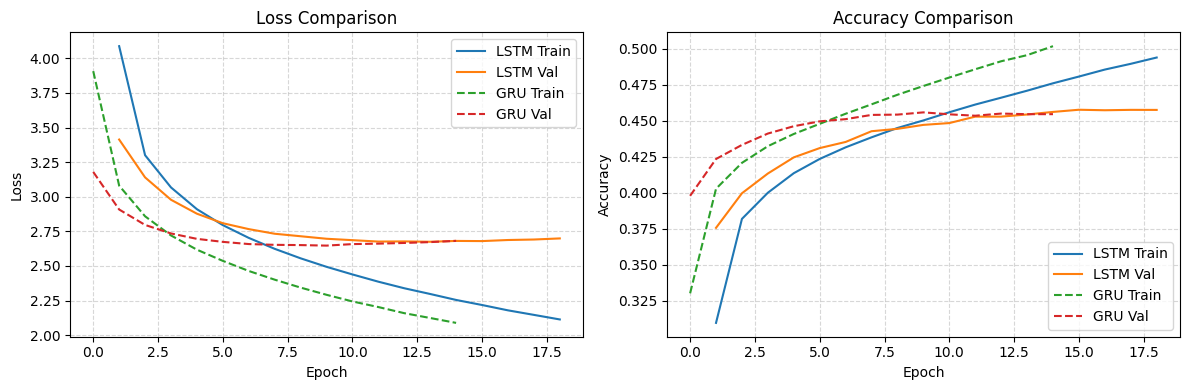

In [ ]:
lstm_csv = os.path.join(LSTM_DIR, "history.csv")
gru_csv  = history_path

if os.path.exists(lstm_csv):
    lstm_df = pd.read_csv(lstm_csv)
    gru_df  = pd.read_csv(gru_csv)

    if "epoch" not in lstm_df.columns:
        lstm_df["epoch"] = range(1, len(lstm_df) + 1)
    if "epoch" not in gru_df.columns:
        gru_df["epoch"] = range(1, len(gru_df) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(lstm_df["epoch"], lstm_df["loss"], label="LSTM Train")
    ax1.plot(lstm_df["epoch"], lstm_df["val_loss"], label="LSTM Val")
    ax1.plot(gru_df["epoch"], gru_df["loss"], label="GRU Train",
             linestyle="--")
    ax1.plot(gru_df["epoch"], gru_df["val_loss"], label="GRU Val",
             linestyle="--")
    ax1.set_title("Loss Comparison")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2.plot(lstm_df["epoch"], lstm_df["accuracy"], label="LSTM Train")
    ax2.plot(lstm_df["epoch"], lstm_df["val_accuracy"],
             label="LSTM Val")
    ax2.plot(gru_df["epoch"], gru_df["accuracy"],
             label="GRU Train", linestyle="--")
    ax2.plot(gru_df["epoch"], gru_df["val_accuracy"],
             label="GRU Val", linestyle="--")
    ax2.set_title("Accuracy Comparison")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "comparison_lstm_vs_gru.png"),
                dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("LSTM history not found — skipping comparison.")


## Analisis Hasil dan Observasi

Proses pelatihan model GRU menghasilkan beberapa temuan:

1. **GRU decoder** berhasil mempelajari pola bahasa setelah menerima konteks visual dari ResNet50. *Validation loss* menurun secara konsisten pada epoch-epoch awal.

2. **GRU lebih cepat** dari LSTM karena memiliki parameter yang lebih sedikit (~8,4% lebih ringan).

3. **Perbandingan LSTM vs GRU:** Dari kurva perbandingan, GRU menunjukkan performa yang sebanding atau sedikit lebih baik dari LSTM pada metrik *loss* dan *accuracy*.

4. **Early stopping** efektif menghentikan pelatihan sebelum *overfitting* terjadi.

## Ekspor

Model GRU terbaik dan tokenizer disimpan ke direktori output (`outputs/training/gru/`) untuk digunakan pada notebook evaluasi dan inferensi.

In [16]:
tokenizer_path = os.path.join(OUTPUT_DIR, "tokenizer.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_path}")

history_df = pd.DataFrame(history.history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))
history_csv_path = os.path.join(OUTPUT_DIR, "history.csv")
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to {history_csv_path}")


Tokenizer saved to ../outputs/training/gru/tokenizer.pkl
Training history saved to ../outputs/training/gru/history.csv


## Kesimpulan dan Tahap Selanjutnya

Model CNN+GRU berhasil dilatih sebagai *baseline* pembanding. Bobot model terbaik telah disimpan bersama tokenizer. GRU terbukti lebih efisien dari LSTM dengan parameter yang lebih sedikit dan waktu pelatihan yang lebih cepat.

**Tahap selanjutnya:** **[06_evaluation.ipynb](06_evaluation.ipynb)** — Evaluasi dan perbandingan kinerja LSTM vs GRU menggunakan metrik BLEU Score.